In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier # untuk perbandingan

from model.network import NeuralNetwork
from model.layers import DenseLayer
from model.activation import ActivationLayer
from main import load_data_placement 

In [74]:
# load dataset
data = pd.read_csv('data/datasetml_2026.csv')

## 1. Exploratory Data Analysis (EDA)

### 1.1 Informasi Umum Data

In [75]:
data.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [77]:
data.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [78]:
# Cek missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [79]:
# Distribusi kelas target
print(data['placement_status'].value_counts())
print(data['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


### 1.2 Visualisasi Data

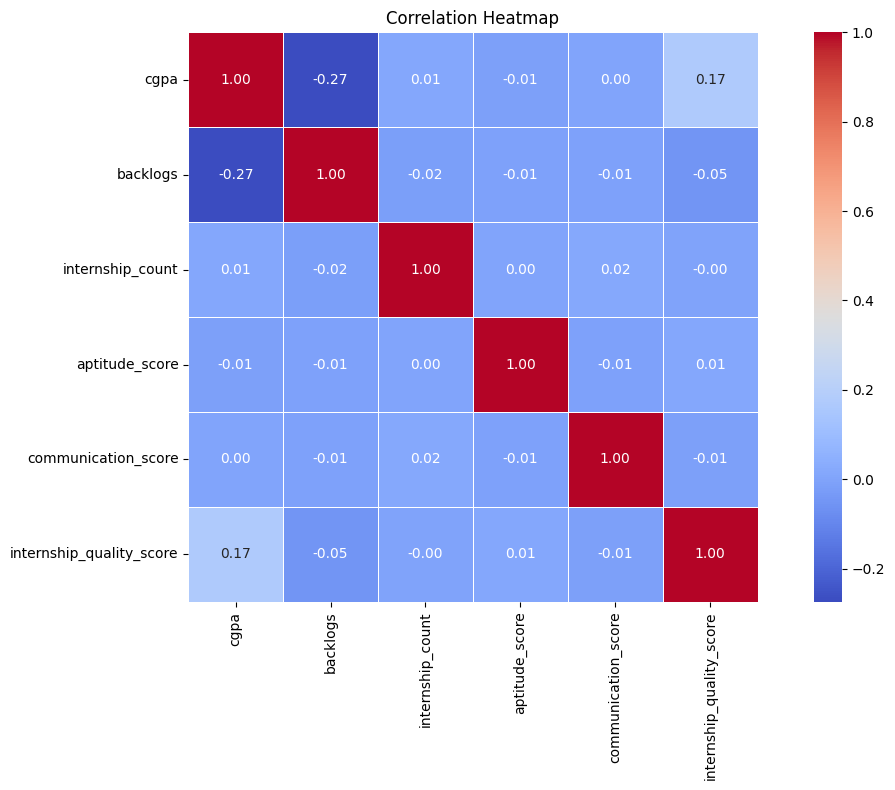

In [80]:
# Snippet: heatmap korelasi fitur numerik
# -------------------------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()


plt.figure(figsize=(12, 8))
corr_matrix = data[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

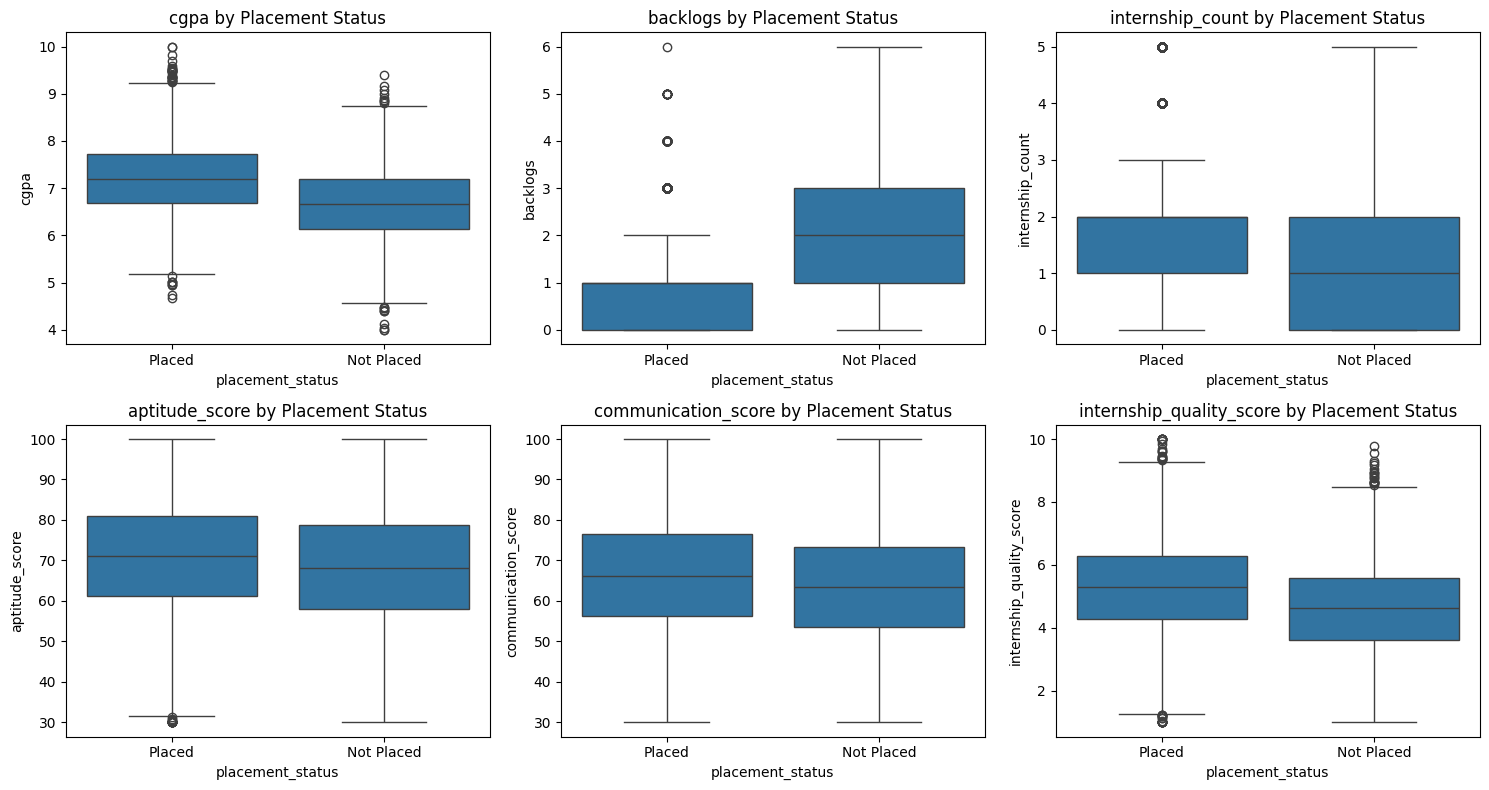

In [81]:
# Snippet: boxplot untuk deteksi outlier per kelas target
# -------------------------------------------------------
num_features = [col for col in num_cols if col != 'placement_status']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    sns.boxplot(data=data, x='placement_status', y=col, ax=ax)
    ax.set_title(f'{col} by Placement Status')

plt.tight_layout()
plt.show()

### 2. Data Cleaning dan Preprocessing

In [82]:
# Salin data
data_copy = data.copy()

In [83]:
TARGET_COL = 'placement_status'

CAT_COLS = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
NUM_COLS = [c for c in data_copy.columns if c not in CAT_COLS + [TARGET_COL]]

print("Categorical Columns:", CAT_COLS)
print("Numerical Columns:", NUM_COLS)

Categorical Columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
Numerical Columns: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


In [85]:
# Handling missing values
# Snippet: SimpleImputer
# -------------------------------------------------------
from sklearn.impute import SimpleImputer


num_imputer = SimpleImputer(strategy='median')  
data_copy[NUM_COLS] = num_imputer.fit_transform(data_copy[NUM_COLS])

cat_imputer = SimpleImputer(strategy='most_frequent')
data_copy[CAT_COLS] = cat_imputer.fit_transform(data_copy[CAT_COLS])


In [86]:
# Handling outlier
# Snippet: Deteksi outlier dengan IQR
# -------------------------------------------------------
def get_iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in NUM_COLS:
    lower, upper = get_iqr_bounds(data_copy[col])
    data_copy[col] = data_copy[col].clip(lower, upper)
    n = ((data_copy[col] < lower) | (data_copy[col] > upper)).sum()


    print(f"{col}: {n} outliers")

cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers


In [87]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Fit hanya di data_copying
encoder.fit(data_copy[CAT_COLS])

# Transform keduanya
data_copy_encoded = encoder.transform(data_copy[CAT_COLS])

data_copy_encoded = pd.DataFrame(
    data_copy_encoded,
    columns=encoder.get_feature_names_out(CAT_COLS),
)


data_copy = pd.concat(
    [data_copy.drop(columns=CAT_COLS), data_copy_encoded],
    axis=1
)


In [88]:
data_copy.head()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,college_tier_Tier 2,college_tier_Tier 3,country_Germany,country_India,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech,placement_status_Placed
0,7.397371,1.0,2.0,53.574150,64.177062,5.481450,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,6.889389,0.0,1.0,60.687750,88.346052,4.625099,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,7.518151,0.0,2.0,64.568750,69.493171,5.227939,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,8.218424,0.0,3.0,73.461500,78.204854,5.150674,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6.812677,1.0,3.5,86.518121,44.680881,3.888824,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [90]:
from sklearn.model_selection import train_test_split


feature_cols = [c for c in data_copy.columns if c not in [TARGET_COL]]

X = data_copy[feature_cols]
y = data_copy['placement_status_Placed']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=42,
    stratify=y          
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (8000, 24) | y_train: (8000,)
X_val:   (2000, 24) | y_val:   (2000,)


### 3. Modeling and Validation

In [92]:
# Helper: evaluasi model dan simpan hasil
from sklearn.metrics import f1_score


results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['Rejected (0)', 'Approved (1)']))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

In [93]:
model = NeuralNetwork()

# to be continued nanti hehe